PART 1 Data Analysis & Preprocessing
-------------------------------------
------------------------------------

In [ ]:
import pandas as pd   #importing required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df=pd.read_csv('../data/penguins.csv')  #reading the dataset
print(df.describe())  #prints main statistics of dataset
print("Dataset Info")
print(df.info())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      342.000000     342.000000         342.000000   342.000000   
mean        43.921930      17.151170         200.915205  4201.754386   
std          5.459584       1.974793          14.061714   801.954536   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.225000      15.600000         190.000000  3550.000000   
50%         44.450000      17.300000         197.000000  4050.000000   
75%         48.500000      18.700000         213.000000  4750.000000   
max         59.600000      21.500000         231.000000  6300.000000   

              year  
count   344.000000  
mean   2008.029070  
std       0.818356  
min    2007.000000  
25%    2007.000000  
50%    2008.000000  
75%    2009.000000  
max    2009.000000  
Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ---

In [12]:
# Imputing missing data
numeric_columns = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')  # Coerce errors to NaN

for column in numeric_columns:       #Filling missing values with the column mean for numeric columns
    mean_value = df[column].mean()  # calculates mean for each numeric column
    df[column].fillna(mean_value)  # Replaces NaN with the mean

df['gender'].fillna(df['gender'].mode()[0]) # replaces missing gender values with most frequently occuring gender.

0        male
1      female
2      female
3        male
4      female
        ...  
339      male
340    female
341      male
342      male
343    female
Name: gender, Length: 344, dtype: str

In [13]:
df['species'] = df['species'].str.capitalize()  # Standardizing the columns
df['gender']=df['gender'].str.lower()
df['island']=df['island'].str.capitalize()

In [14]:
# Detection and removing of outliers in flipper_length_mm using interquartile range (IQR)
P1 = df['flipper_length_mm'].quantile(0.25)
P3 = df['flipper_length_mm'].quantile(0.75)
IQR = P3 - P1

outlier_thres = (P1 - 1.5 * IQR, P3 + 1.5 * IQR)
df_no_outliers = df[~((df['flipper_length_mm'] < outlier_thres[0]) |
                          (df['flipper_length_mm'] > outlier_thres[1]))]

# replacing outliers with the mean or median
df['flipper_length_mm'] = np.where((df['flipper_length_mm'] < outlier_thres[0]) |
                                     (df['flipper_length_mm'] > outlier_thres[1]),
                                     df['flipper_length_mm'].median(), df['flipper_length_mm'])


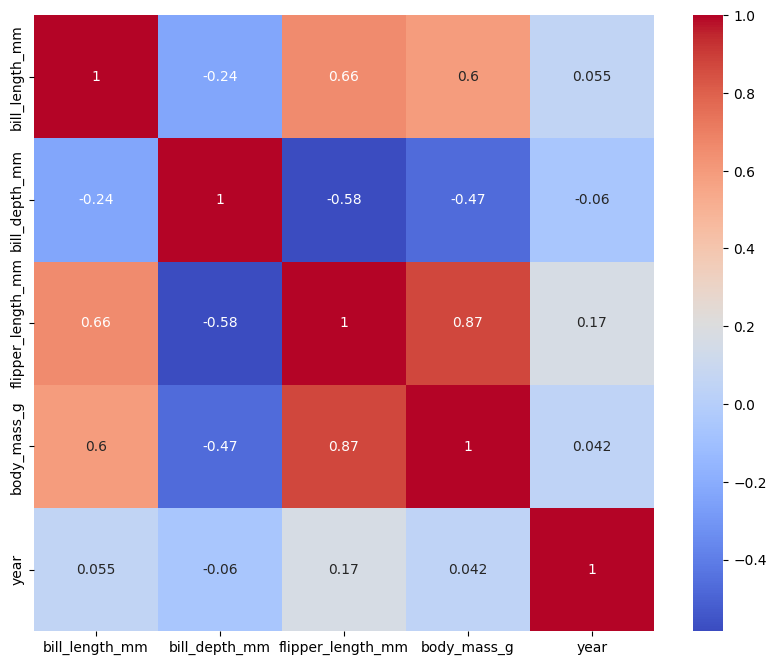

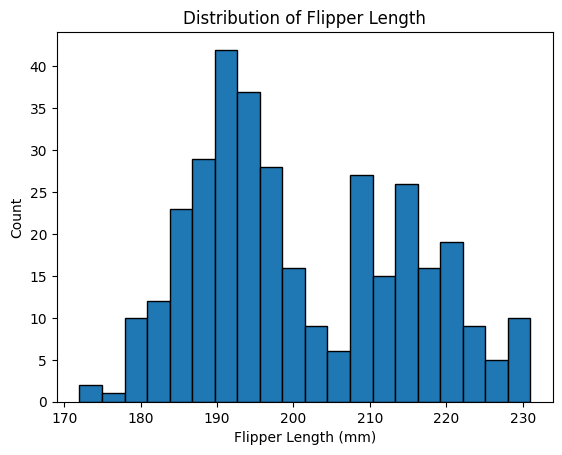

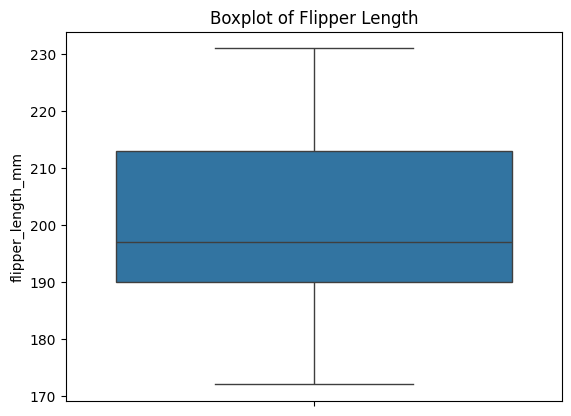

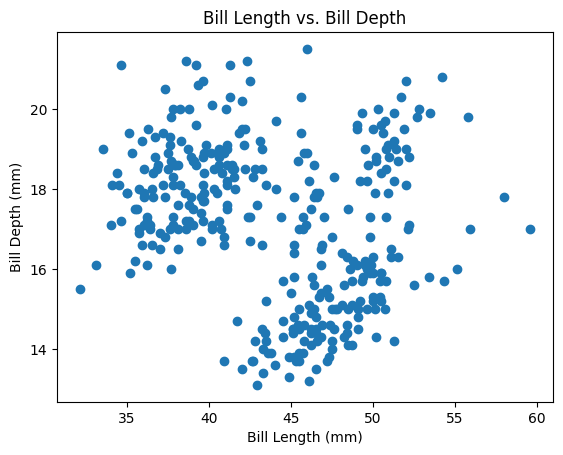

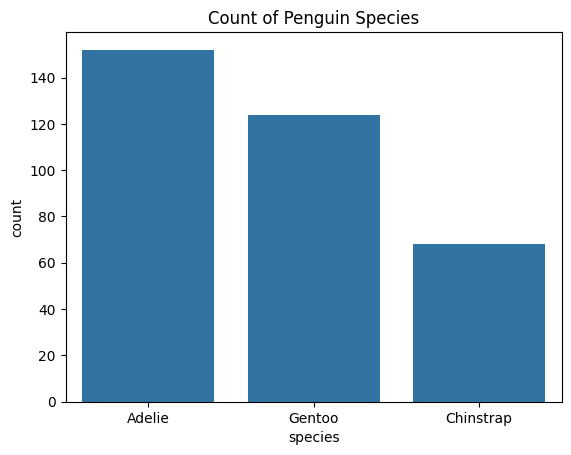

In [15]:
plt.figure(figsize=(10, 8))               # Gives Correlation heatmap
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')  # Calculates correlation on numeric data
plt.show()

# Histogram of numeric column
plt.hist(df['flipper_length_mm'], bins=20, edgecolor='black')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Count')
plt.title('Distribution of Flipper Length')
plt.show()

# Boxplot for detecting outliers
sns.boxplot(df['flipper_length_mm'])
plt.title('Boxplot of Flipper Length')
plt.show()

# Scatter plot of bill length vs bill depth
plt.scatter(df['bill_length_mm'], df['bill_depth_mm'])
plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.title('Bill Length vs. Bill Depth')
plt.show()

# Count plot of categorical feature
sns.countplot(x='species', data=df)  # Make sure 'species' column exists
plt.title('Count of Penguin Species')
plt.show()

In [16]:
import pickle
numeric_feature_df = df.select_dtypes(include=np.number)# Selecting only numeric features for correlation analysis
correlation_matrix = numeric_feature_df.corr()          # Calculate correlation matrix

# Drop features with correlation coefficient below a threshold
threshold = 0.5
low_corr_features = correlation_matrix[correlation_matrix.abs() < threshold].index
data_dropped = df.drop(columns=low_corr_features, errors='ignore') #Ignore errors if

In [17]:
# Normalization (Min-Max Scaling)
#Select only numeric features for normalization
numeric_df = df.select_dtypes(include=np.number)

# Perform normalization on numeric features only
data_normalized = (numeric_df - numeric_df.min()) / (numeric_df.max() - numeric_df.min())

# If you need to re-combine with the original DataFrame:
df[data_normalized.columns] = data_normalized
print(df.head(15))
df.to_csv('cleaned_penguins.csv', index=False)

   species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0   Adelie  Torgersen        0.254545       0.666667           0.152542   
1   Adelie  Torgersen        0.269091       0.511905           0.237288   
2   Adelie  Torgersen        0.298182       0.583333           0.389831   
3   Adelie  Torgersen             NaN            NaN                NaN   
4   Adelie  Torgersen        0.167273       0.738095           0.355932   
5   Adelie  Torgersen        0.261818       0.892857           0.305085   
6   Adelie  Torgersen        0.247273       0.559524           0.152542   
7   Adelie  Torgersen        0.258182       0.773810           0.389831   
8   Adelie  Torgersen        0.072727       0.595238           0.355932   
9   Adelie  Torgersen        0.360000       0.845238           0.305085   
10  Adelie  Torgersen        0.207273       0.476190           0.237288   
11  Adelie  Torgersen        0.207273       0.500000           0.135593   
12  Adelie  Torgersen    

In [20]:

# Loading Data
file_path = '../data/emissions_by_country.csv'
df = pd.read_csv(file_path)


In [21]:
# Prints Main Statistics
print("Initial Data Overview:")
print(df.info())
print(df.describe())


Initial Data Overview:
<class 'pandas.DataFrame'>
RangeIndex: 63104 entries, 0 to 63103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               61087 non-null  str    
 1   ISO 3166-1 alpha-3    59483 non-null  str    
 2   Year                  62307 non-null  float64
 3   Total                 62381 non-null  float64
 4   Temperature           63104 non-null  int64  
 5   GDP Per Capita (USD)  63104 non-null  int64  
 6   Coal                  21797 non-null  float64
 7   Oil                   21774 non-null  float64
 8   Gas                   21717 non-null  float64
 9   Cement                20488 non-null  float64
 10  Flaring               21338 non-null  float64
 11  Other                 2685 non-null   float64
 12  Per Capita            19392 non-null  float64
dtypes: float64(9), int64(2), str(2)
memory usage: 6.3 MB
None
               Year         Total   Temperature  GD

In [22]:
#Handling missing values and imputing missing data
df= df[df['Total'] != 0]
df = df.dropna(subset=['Total'])
df=df.drop('Other',axis=1)
df = df.dropna(subset=['Country'])
df = df[df['Country'].str.strip() != '']
df['Country'] = df['Country'].str.title()  # Converts to title case

df = df.dropna(subset=['Year'])  # Removing rows where 'Year' could not be converted into a number
df = df.sort_values(by=['Country', 'Year'], ascending=[True, True])  # Sort by Country and Year
df=df.dropna(subset=["ISO 3166-1 alpha-3"])

In [23]:
#Handling duplicate rows if necessary
df = df.drop_duplicates(subset=['Country', 'Year'], keep='last')
columns_to_check = ['Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Per Capita']

def remove_outliers_E(df, columns):
    # Grouping by 'Country'
    grouped = df.groupby('Country')
    # Defines list to collect indices to drop
    indices_to_drop = []

    # Iterates through each group
    for name, group in grouped:
        for column in columns:
            # Calculates Q1 and Q3 for the current column
            Q1 = group[column].quantile(0.25)
            Q3 = group[column].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Identifys indices of outliers for the current column
            outlierr = group[(group[column] < lower_bound) | (group[column] > upper_bound)].index

            # Append outlier indices to the list
            indices_to_drop.extend(outlierr)

    # Drop soutliers from the original dataframe
    cleaned_df = df.drop(list(set(indices_to_drop))).reset_index(drop=True)
    return cleaned_df



In [24]:
# Applying the function to remove outliers
cleaned_emissions_df = remove_outliers_E(df, columns_to_check)

def replace_zero_nan_with_mean(df, columns):
    for column in columns:
        non_zero_mean = df[df[column] != 0][column].mean()

        # Replaces zeros with the column mean
        df[column] = df[column].replace(0, np.nan)  # Firsty replace zeros with NaN
        df[column].fillna(non_zero_mean, inplace=True)  # Then fill NaNs with mean

    return df


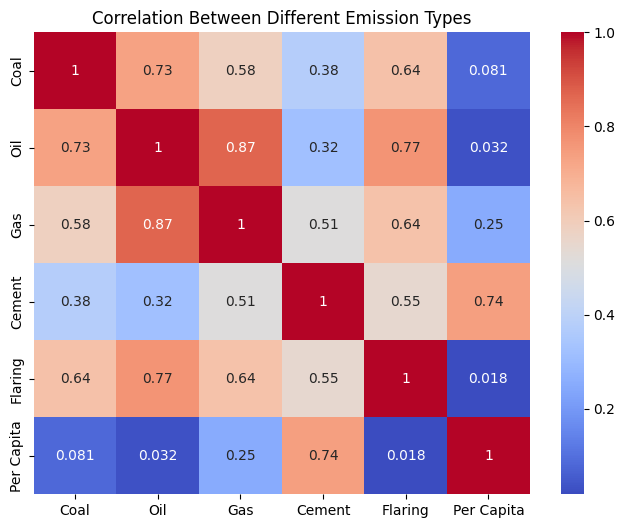

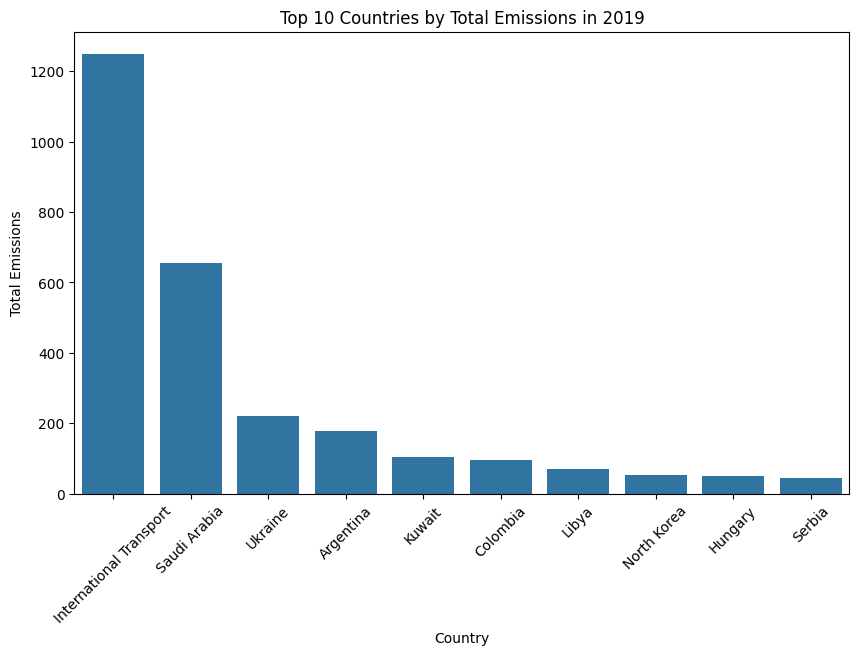

<Figure size 800x600 with 0 Axes>

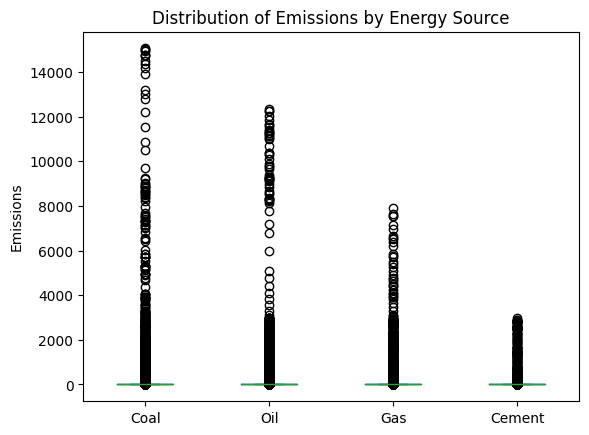

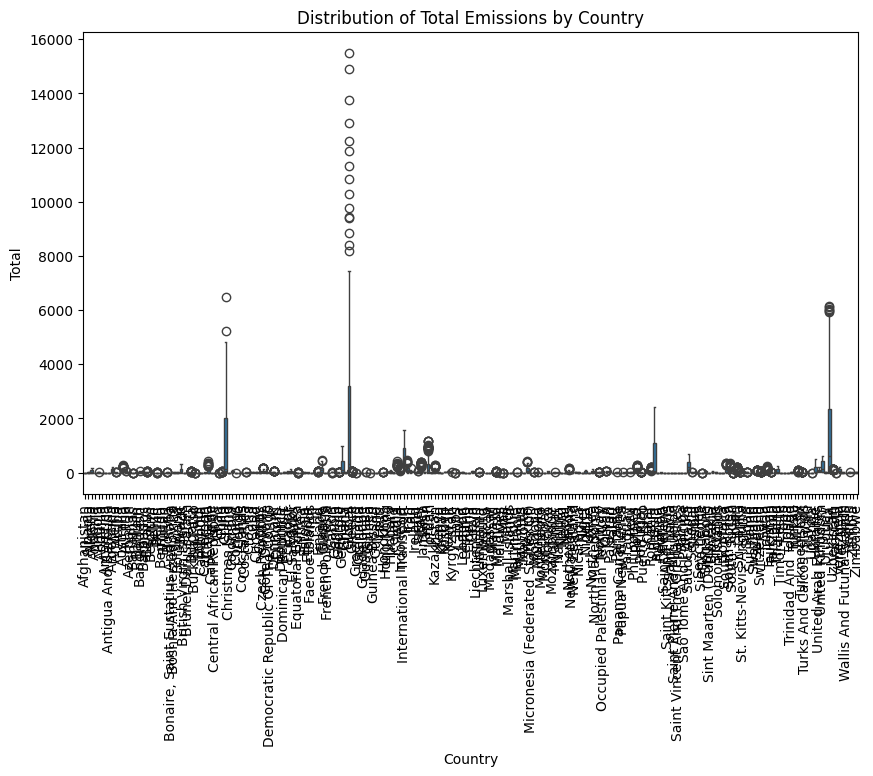

In [25]:
#Graphs
# Correlation Matrix
plt.figure(figsize=(8, 6))
correlation_matrix = cleaned_emissions_df[['Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Per Capita']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Between Different Emission Types')
plt.show()

# Bar Plot of Top 10 Countries by Total Emissions in a Specific Year
year = 2019
top_countries = cleaned_emissions_df[cleaned_emissions_df['Year'] == year].sort_values(by='Total', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x='Country', y='Total', data=top_countries)
plt.title(f'Top 10 Countries by Total Emissions in {year}')
plt.ylabel('Total Emissions')
plt.xticks(rotation=45)
plt.show()


# Distribution of Emissions by Energy Source
plt.figure(figsize=(8, 6))
df[['Coal', 'Oil', 'Gas', 'Cement']].plot(kind='box')
plt.title('Distribution of Emissions by Energy Source')
plt.ylabel('Emissions')
plt.show()

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Country', y='Total', data=cleaned_emissions_df)
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.title('Distribution of Total Emissions by Country')
plt.show()


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
file_path = '../data/diamond.csv'
df = pd.read_csv(file_path)

# Displaying the first few rows of the dataset
df.head(), df.info()


<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Unnamed: 0                           53563 non-null  str    
 1   carat                                52430 non-null  str    
 2   cut                                  52647 non-null  str    
 3   color                                52428 non-null  str    
 4   clarity                              53587 non-null  str    
 5   average us salary                    53940 non-null  int64  
 6   number of diamonds mined (millions)  53940 non-null  float64
 7   depth                                53246 non-null  str    
 8   table                                52398 non-null  str    
 9   price                                52357 non-null  str    
 10  x                                    52414 non-null  str    
 11  y                                    52

(  Unnamed: 0 carat      cut color clarity  average us salary  \
 0          1  0.23    Ideal     E     SI2              31282   
 1          2  0.21  Premium     E     SI1              40049   
 2          3  0.23     Good     E     VS1              33517   
 3          4  0.29  Premium     I     VS2              38495   
 4          5  0.31     Good     J     SI2              34178   
 
    number of diamonds mined (millions) depth table price     x     y     z  
 0                                 5.01  61.5    55   326  3.95  3.98  2.43  
 1                                 1.69  59.8    61   326  3.89  3.84  2.31  
 2                                 3.85  56.9    65   327  4.05  4.07  2.31  
 3                                 3.49  62.4    58   334   4.2  4.23  2.63  
 4                                 4.70  63.3    58   335  4.34  4.35  2.75  ,
 None)

In [27]:

# Droping 'Unnamed: 0' column
df_cleaned = df.drop(columns=['Unnamed: 0'])

# Converts columns that should be numeric to numeric, coercing errors to NaN for invalid entries
numeric_columns = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
df_cleaned[numeric_columns] = df_cleaned[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Checks the percentage of missing values for each column
missing_values = df_cleaned.isnull().mean() * 100
print("Percentage of Missing Values:")
print(missing_values)

# Filling missing values:
# for categorical columns we can fill with most frequent value
# replacing missing values in numeric colums with median
df_cleaned['carat'] = df_cleaned['carat'].fillna(df_cleaned['carat'].median())
df_cleaned['cut'] = df_cleaned['cut'].fillna(df_cleaned['cut'].mode()[0])
df_cleaned['color'] = df_cleaned['color'].fillna(df_cleaned['color'].mode()[0])
df_cleaned['clarity'] = df_cleaned['clarity'].fillna(df_cleaned['clarity'].mode()[0])
df_cleaned['depth'] = df_cleaned['depth'].fillna(df_cleaned['depth'].median())
df_cleaned['table'] = df_cleaned['table'].fillna(df_cleaned['table'].median())
df_cleaned['price'] = df_cleaned['price'].fillna(df_cleaned['price'].median())
df_cleaned['x'] = df_cleaned['x'].fillna(df_cleaned['x'].median())
df_cleaned['y'] = df_cleaned['y'].fillna(df_cleaned['y'].median())
df_cleaned['z'] = df_cleaned['z'].fillna(df_cleaned['z'].median())




Percentage of Missing Values:
carat                                  5.315165
cut                                    2.397108
color                                  2.803115
clarity                                0.654431
average us salary                      0.000000
number of diamonds mined (millions)    0.000000
depth                                  3.845013
table                                  5.394883
price                                  3.885799
x                                      5.400445
y                                      3.210975
z                                      4.464220
dtype: float64


In [28]:
df.describe()

,average us salary,number of diamonds mined (millions)
count,53940.000000,53940.000000
mean,39521.990100,2.902669
std,5486.892971,1.325985
min,30000.000000,0.600000
25%,34780.000000,1.750000
50%,39547.500000,2.910000
75%,44252.000000,4.050000
max,48999.000000,5.200000


In [29]:
def remove_outliers_D(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Removes outliers from numeric columns
numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
for col in numeric_cols:
    df_cleaned = remove_outliers_D(df_cleaned, col)


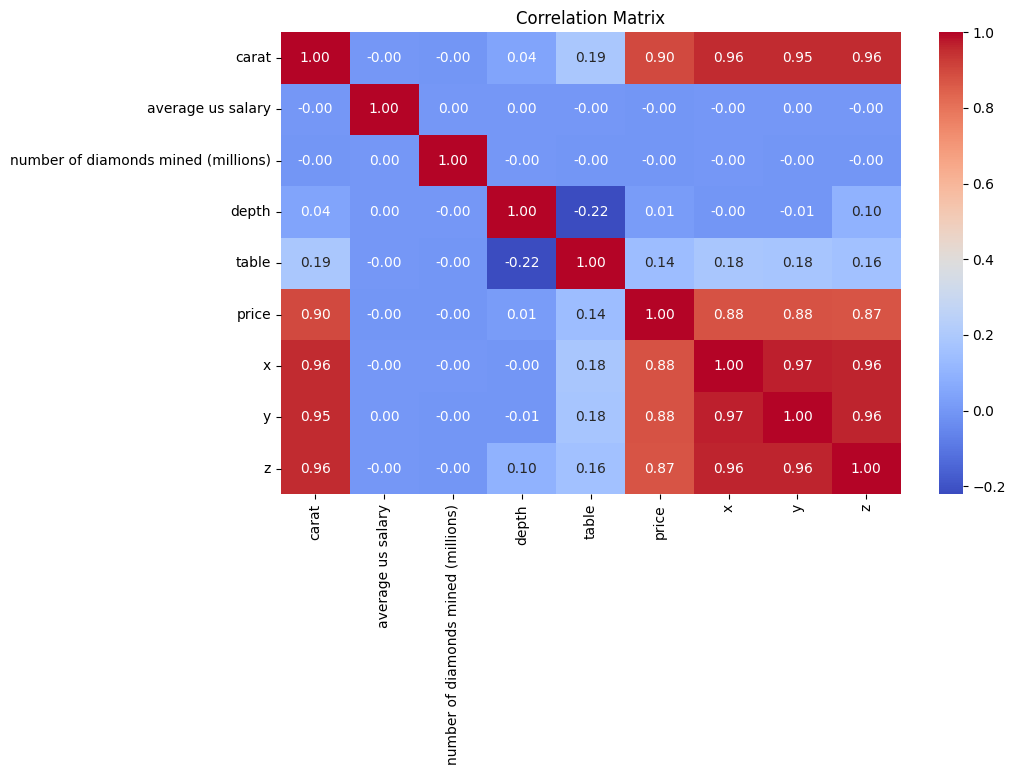

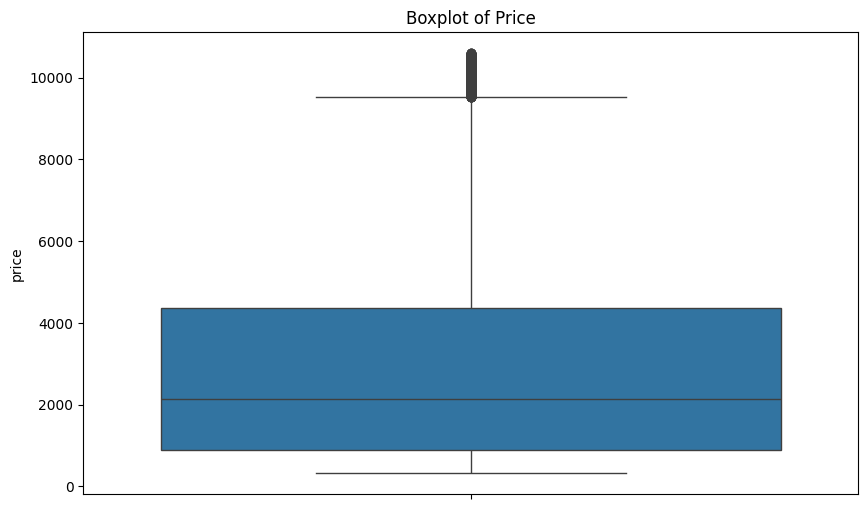

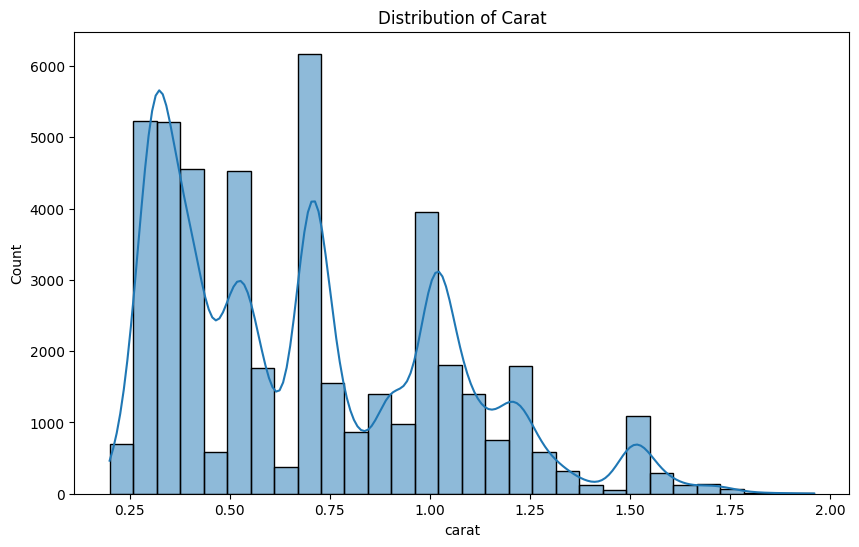

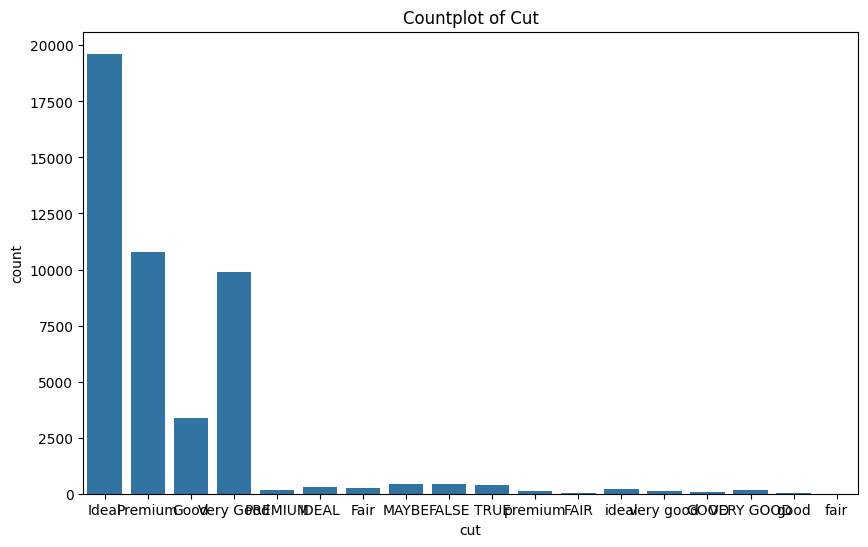

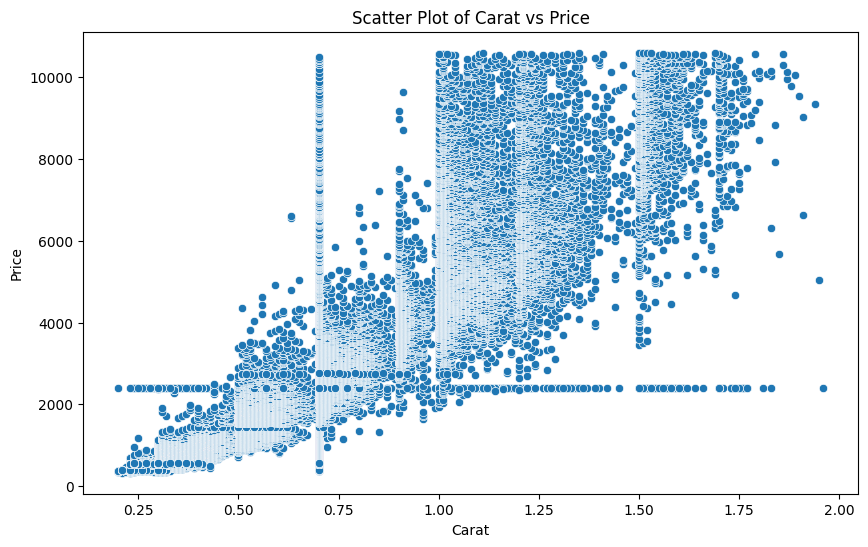

In [30]:
# Graphs

# Correlation heatmap
plt.figure(figsize=(10,6))

# Selects only numeric columns for calculating correlation
numeric_df = df_cleaned.select_dtypes(include=['number'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Boxplot for 'price' column
plt.figure(figsize=(10, 6))
sns.boxplot(df_cleaned['price'])
plt.title('Boxplot of Price')
plt.show()

# Histogram for 'carat'
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['carat'], bins=30, kde=True)
plt.title('Distribution of Carat')
plt.show()

# Countplot of 'cut'
plt.figure(figsize=(10, 6))
sns.countplot(x='cut', data=df_cleaned)
plt.title('Countplot of Cut')
plt.show()

# scatter plot for  carat vs price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='carat', y='price', data=df_cleaned)
plt.title('Scatter Plot of Carat vs Price')
plt.xlabel('Carat')
plt.ylabel('Price')
plt.show()



In [31]:
# saving the cleaned dataset
df_cleaned.info(), df_cleaned.head()
df_cleaned.to_csv('diamond_preprocessed.csv', index=False)

<class 'pandas.DataFrame'>
Index: 46415 entries, 0 to 53939
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   carat                                46415 non-null  float64
 1   cut                                  46415 non-null  str    
 2   color                                46415 non-null  str    
 3   clarity                              46415 non-null  str    
 4   average us salary                    46415 non-null  int64  
 5   number of diamonds mined (millions)  46415 non-null  float64
 6   depth                                46415 non-null  float64
 7   table                                46415 non-null  float64
 8   price                                46415 non-null  float64
 9   x                                    46415 non-null  float64
 10  y                                    46415 non-null  float64
 11  z                                    46415 n

In [32]:
# Loading the dataset
df = pd.read_csv('../data/emissions_by_country.csv')

# Prints initial data overview
print("Initial Data Overview:")
print(df.info())
print(df.describe())


Initial Data Overview:
<class 'pandas.DataFrame'>
RangeIndex: 63104 entries, 0 to 63103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               61087 non-null  str    
 1   ISO 3166-1 alpha-3    59483 non-null  str    
 2   Year                  62307 non-null  float64
 3   Total                 62381 non-null  float64
 4   Temperature           63104 non-null  int64  
 5   GDP Per Capita (USD)  63104 non-null  int64  
 6   Coal                  21797 non-null  float64
 7   Oil                   21774 non-null  float64
 8   Gas                   21717 non-null  float64
 9   Cement                20488 non-null  float64
 10  Flaring               21338 non-null  float64
 11  Other                 2685 non-null   float64
 12  Per Capita            19392 non-null  float64
dtypes: float64(9), int64(2), str(2)
memory usage: 6.3 MB
None
               Year         Total   Temperature  GD

In [33]:
# Handling missing values and imputing missing data
# Remove rows with zero total emissions
df = df.drop('Other', axis=1)
df = df[df['Total'] != 0]

# Drop rows where 'Total' and 'Country' are NaN
df = df.dropna(subset=['Total', 'Country'])

# Clean 'Country' column
df['Country'] = df['Country'].str.title().str.strip()  # Converts to title case and strips whitespace
df = df[df['Country'] != '']  # Remove empty country names
df = df.dropna(subset=['Year'])
df = df.sort_values(by=['Country', 'Year'], ascending=[True, True])
df = df.dropna(subset=["ISO 3166-1 alpha-3"])

# Handling duplicate rows
df = df.drop_duplicates(subset=['Country', 'Year'], keep='last')

# Defines columns to check for outliers
columns_to_check = ['Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Per Capita']


In [34]:

# Function to remove outliers based on IQR
def remove_outliers_E(df, columns):
    # Grouping by 'Country'
    grouped = df.groupby('Country')
    indices_to_drop = []

    for name, group in grouped:
        for column in columns:
            Q1 = group[column].quantile(0.25)
            Q3 = group[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outlier_indices = group[(group[column] < lower_bound) | (group[column] > upper_bound)].index
            indices_to_drop.extend(outlier_indices)

    # Drop outliers from the original DataFrame
    cleaned_df = df.drop(list(set(indices_to_drop))).reset_index(drop=True)
    return cleaned_df

# Apply the function to remove outliers
cleaned_emissions_df = remove_outliers_E(df, columns_to_check)


In [35]:
# Function to replace zeros with mean
def replace_zero_nan_with_mean(df, columns):
    for column in columns:
        non_zero_mean = df[df[column] != 0][column].mean()
        df[column].replace(0, np.nan, inplace=True)  # Replaces zeros with NaN
        df[column].fillna(non_zero_mean, inplace=True)  # Fills NaNs with mean
    return df

# Apply the function to replace zeros with mean
cleaned_emissions_df = replace_zero_nan_with_mean(cleaned_emissions_df, columns_to_check)

# Check for remaining missing values
print("Missing values after preprocessing:")
print(cleaned_emissions_df.isnull().sum())


Missing values after preprocessing:
Country                    0
ISO 3166-1 alpha-3         0
Year                       0
Total                      0
Temperature                0
GDP Per Capita (USD)       0
Coal                     112
Oil                      198
Gas                      286
Cement                  3949
Flaring                  343
Per Capita              4085
dtype: int64


/var/folders/cq/5xpf_5tn1gv0d6gdfjyvbf7c0000gn/T/ipykernel_8293/704644288.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[column].replace(0, np.nan, inplace=True)  # Replaces zeros with NaN
/var/folders/cq/5xpf_5tn1gv0d6gdfjyvbf7c0000gn/T/ipykernel_8293/704644288.py:6: ChainedAssignmentError: A value is being set on a copy of 

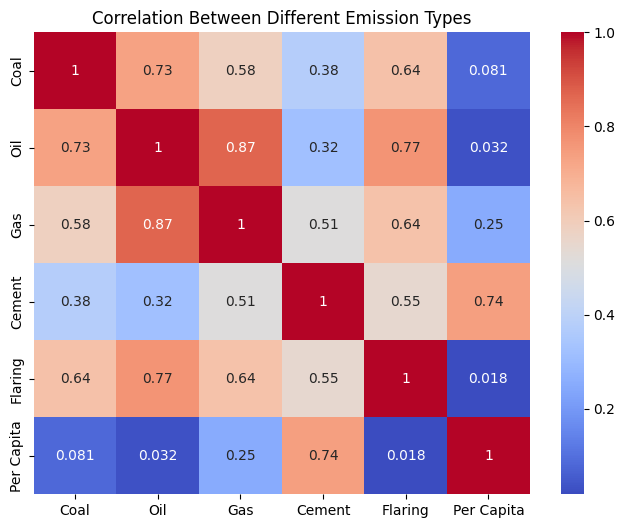

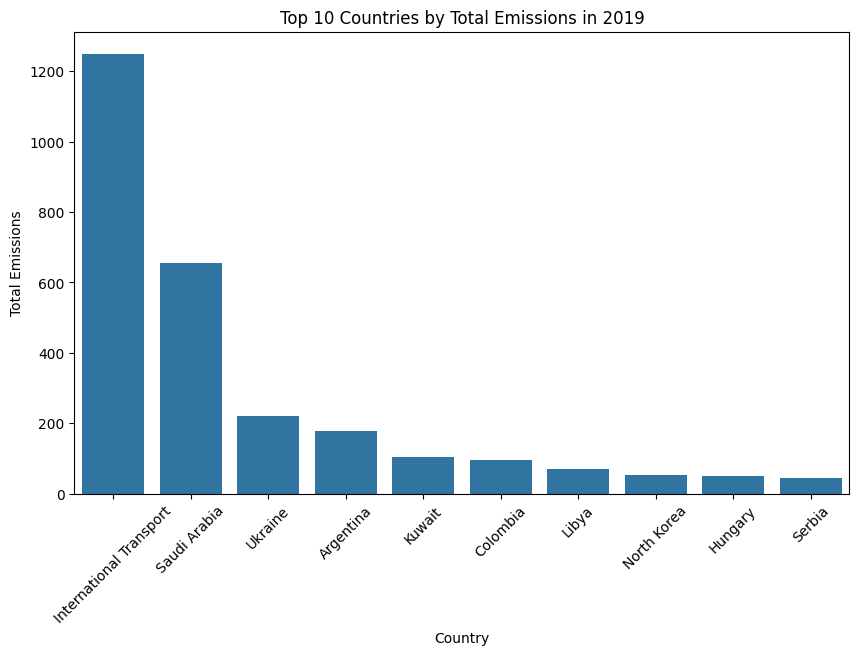

<Figure size 800x600 with 0 Axes>

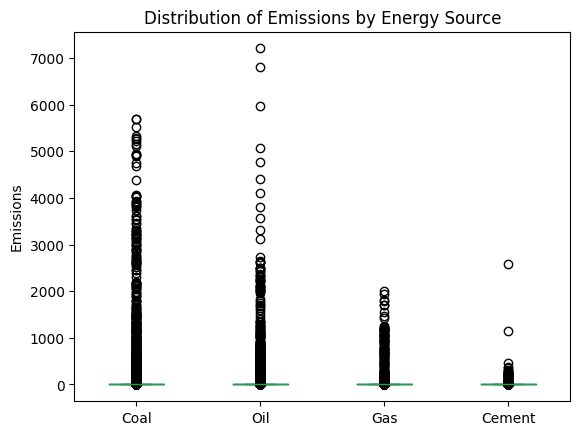

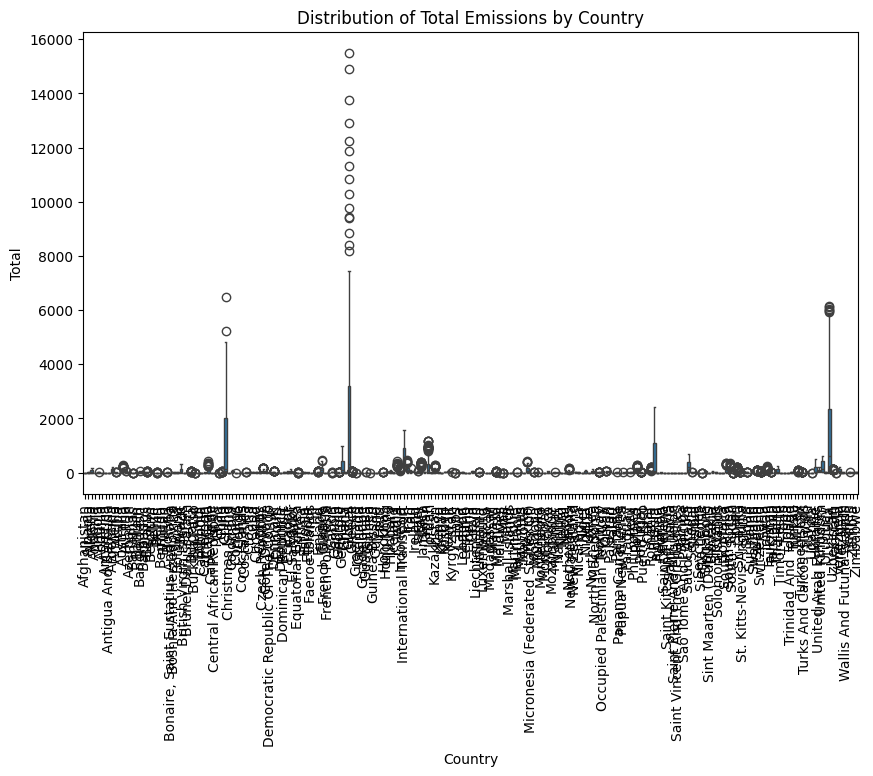

In [37]:
# Correlation Matrix
plt.figure(figsize=(8, 6))
correlation_matrix = cleaned_emissions_df[['Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Per Capita']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Between Different Emission Types')
plt.show()

# Bar Plot of Top 10 Countries by Total Emissions in a Specific Year
year = 2019
top_countries = cleaned_emissions_df[cleaned_emissions_df['Year'] == year].sort_values(by='Total', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x='Country', y='Total', data=top_countries)
plt.title(f'Top 10 Countries by Total Emissions in {year}')
plt.ylabel('Total Emissions')
plt.xticks(rotation=45)
plt.show()

# Boxplot for Distribution of Emissions by Energy Source
plt.figure(figsize=(8, 6))
cleaned_emissions_df[['Coal', 'Oil', 'Gas', 'Cement']].plot(kind='box')
plt.title('Distribution of Emissions by Energy Source')
plt.ylabel('Emissions')
plt.show()

# Boxplot for Total Emissions by Country
plt.figure(figsize=(10, 6))
sns.boxplot(x='Country', y='Total', data=cleaned_emissions_df)
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.title('Distribution of Total Emissions by Country')
plt.show()

In [ ]:
'References used = https://www.w3schools.com/python,https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html,https://www.geeksforgeeks.org/introduction-to-seaborn-python/https://www.javatpoint.com/data-preprocessing-machine-learning'

'References used = https://www.w3schools.com/python,https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html,https://www.geeksforgeeks.org/introduction-to-seaborn-python/https://www.javatpoint.com/data-preprocessing-machine-learning'